# Capstone 3: NYC Taxi Data Wrangling, EDA & Modeling

## Objective
The goal of this project is to clean, explore, and analyze NYC taxi trip data to understand the key factors that influence trip duration. Machine learning models are then applied to evaluate how well trip duration can be predicted based on these factors.

## Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

## Preprocessing and Modeling

This section prepares the dataset for modeling and applies machine learning algorithms to predict trip duration. Data is split, scaled where appropriate, and multiple models are trained and evaluated.

### Data Preparation

In [2]:
df = pd.read_csv('../data/yellow_tripdata_2015-01.csv', nrows=100000)

In [3]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [4]:
df['trip_duration'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

In [5]:
# Remove invalid and extreme values
df = df[
    (df['trip_duration'] > 0) &
    (df['trip_duration'] < 300) &
    (df['trip_distance'] > 0) &
    (df['passenger_count'] > 0)
]

In [6]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

In [7]:
y = df['trip_duration']

X = df.drop(columns=[
    'trip_duration',
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'pickup_day',
    'store_and_fwd_flag'
])

### Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)

In [9]:
print(X_train.shape)
print(X_test.shape)

(79393, 17)
(19849, 17)


### Feature Scaling

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

Three models are trained and evaluated to compare performance and understand how different approaches capture relationships in the data.

### Linear Regression

In [11]:
# Train baseline Linear Regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

#### Evaluation

In [12]:
# Evaluate model performance using R² and RMSE
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 5.000039097381088
Linear Regression R2: 0.7172756190285241


### Ridge Regression

In [13]:
# Train Ridge Regression model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

#### Evaluation

In [14]:
# Evaluate model performance using R² and RMSE
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge R2:", r2_ridge)
print("Ridge RMSE:", rmse_ridge)

Ridge R2: 0.7167854466534702
Ridge RMSE: 5.004371620189436


### Random Forest

In [15]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=13
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

#### Evaluation

In [16]:
# Evaluate model performance using R² and RMSE
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R2:", r2_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest R2: 0.8775752485575231
Random Forest RMSE: 3.290230961598835


#### Feature Importance

Feature importance is used to identify which variables contribute most to the Random Forest model’s predictions.

In [17]:
# Extract and sort feature importance scores from the Random Forest model
feature_importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importances.head(10))

fare_amount          0.828276
trip_distance        0.090255
pickup_hour          0.018091
dropoff_longitude    0.013956
dropoff_latitude     0.010587
pickup_longitude     0.009190
pickup_latitude      0.008617
total_amount         0.007420
RateCodeID           0.002876
tip_amount           0.002794
dtype: float64


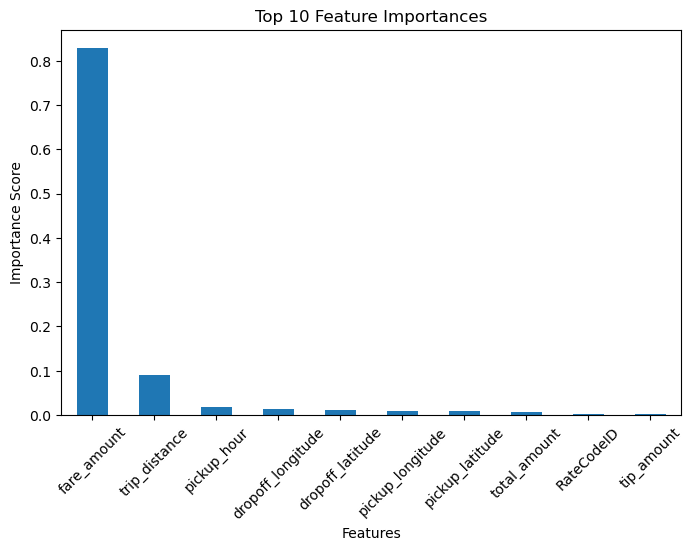

In [18]:
# Visualize the top 10 most important features
plt.figure(figsize=(8,5))

feature_importances.head(10).plot(kind='bar')

plt.title('Top 10 Feature Importances')
plt.ylabel('Importance Score')
plt.xlabel('Features')

plt.xticks(rotation=45)

plt.show()

The Random Forest model identified fare amount and trip distance as the strongest predictors of trip duration. This is expected, as longer trips generally travel farther and result in higher fares. While fare-related variables are highly associated with trip duration, they likely reflect information generated during the trip itself rather than acting as independent drivers of travel time.

In [19]:
# Remove fare-related variables and retrain the model to assess
# how independent trip features influence trip duration
y = df['trip_duration']

X_no_fare = df.drop(columns=[
    'trip_duration',
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'pickup_day',
    'store_and_fwd_flag',
    'fare_amount',
    'total_amount',
    'tip_amount',
    'tolls_amount',
    'mta_tax',
    'extra',
    'improvement_surcharge'
])

In [20]:
X_no_fare_train, X_no_fare_test, y_train, y_test = train_test_split(X_no_fare, y, test_size=0.2, random_state=13)

In [21]:
# Refit the Random Forest model after removing fare-related variables
rf_no_fare = RandomForestRegressor(
    n_estimators=100,
    random_state=13
)

rf_no_fare.fit(X_no_fare_train, y_train)

y_pred_rf_no_fare = rf_no_fare.predict(X_no_fare_test)

In [22]:
r2_rf_no_fare = r2_score(y_test, y_pred_rf_no_fare)
rmse_rf_no_fare = np.sqrt(mean_squared_error(y_test, y_pred_rf_no_fare))

print("Refined RF R2:", r2_rf_no_fare)
print("Refined RF RMSE:", rmse_rf_no_fare)

Refined RF R2: 0.7391029452826521
Refined RF RMSE: 4.80315229904257


In [23]:
# Extract and sort feature importance scores from the refined Random Forest model
feature_importances_no_fare = pd.Series(
    rf_no_fare.feature_importances_,
    index=X_no_fare.columns
).sort_values(ascending=False)

print(feature_importances_no_fare.head(10))

trip_distance        0.718578
pickup_hour          0.058388
dropoff_latitude     0.054054
dropoff_longitude    0.051871
pickup_longitude     0.047028
pickup_latitude      0.045880
passenger_count      0.008415
payment_type         0.006501
RateCodeID           0.004791
VendorID             0.004494
dtype: float64


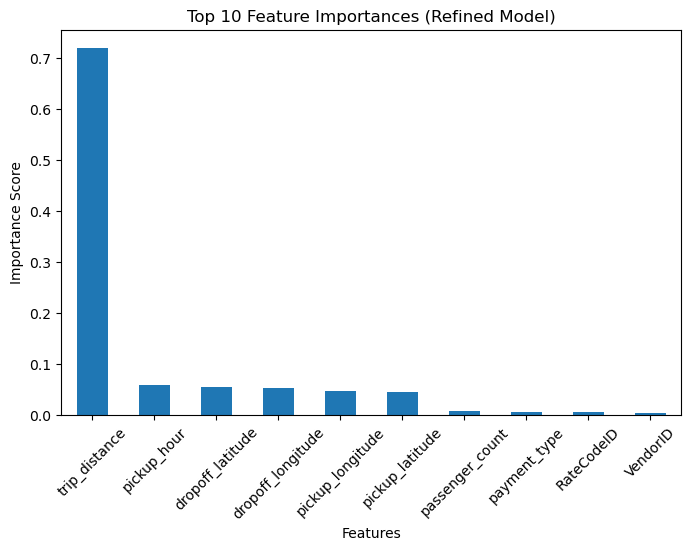

In [24]:
# Visualize the top 10 most important refined features
plt.figure(figsize=(8,5))

feature_importances_no_fare.head(10).plot(kind='bar')

plt.title('Top 10 Feature Importances (Refined Model)')
plt.ylabel('Importance Score')
plt.xlabel('Features')

plt.xticks(rotation=45)

plt.show()

After removing fare-related variables, trip distance emerged as the strongest predictor of trip duration. Time-based and geographic features, such as pickup hour and location coordinates, also contributed to prediction performance. This refined model provides a more realistic view of the independent factors associated with taxi travel time.

## Model Comparison

The performance of each model is compared using R² and RMSE to evaluate predictive accuracy and overall model effectiveness.

In [25]:
model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Random Forest',
        'Refined Random Forest'
    ],
    'R2': [
        r2_lr,
        r2_ridge,
        r2_rf,
        r2_rf_no_fare
    ],
    'RMSE': [
        rmse_lr,
        rmse_ridge,
        rmse_rf,
        rmse_rf_no_fare
    ]
})

model_results

,Model,R2,RMSE
0,Linear Regression,0.717276,5.000039
1,Ridge Regression,0.716785,5.004372
2,Random Forest,0.877575,3.290231
3,Refined Random Forest,0.739103,4.803152


While the original Random Forest model achieved the highest predictive performance, the refined Random Forest model provides a more realistic interpretation of the independent variables associated with trip duration by removing fare-related features closely tied to the completed trip.

## Modeling Summary

Linear Regression and Ridge Regression produced similar results, explaining approximately 71% of the variance in trip duration. The original Random Forest model achieved the strongest predictive performance overall, with the highest R² score and lowest RMSE value.

Feature importance analysis revealed that fare-related variables dominated the original Random Forest model, suggesting that these variables contained substantial information closely tied to trip duration. To better evaluate the independent factors influencing travel time, a refined Random Forest model was trained after removing fare-related variables.

Although the refined Random Forest model produced slightly lower predictive performance, trip distance emerged as the strongest independent predictor of trip duration, followed by time-based and geographic features. This refined model provides a more realistic and interpretable representation of the factors associated with NYC taxi travel time.